# YOLO-Based Vehicle Speed Estimation from Aerial Video

In this project, I fine-tuned **YOLOv8** on the **UAVDT** aerial-vehicle dataset and then used it with the **DeepSORT** tracking on a drone video to estimate each vehicle's speed (in km/h).


**Pipeline**

1. **Data preparation**: convert UAVDT annotations to YOLO format (sequence-level train/val split).
2. **Training**: transfer learning from the pre-trained `yolov8s` with drone-friendly augmentations like vertical flips, rotation, and mosaic.
3. **Evaluation**: mAP@50 and mAP@50-95 at several inference resolutions.
4. **Inference**: detect, then track with DeepSORT, then estimate speed using an auto-calibrated pixel-to-metre scale.
5. **Comparison**: compare YOLOv8 vs. UAVDT-fine-tuned detector on the same video.


# Setup
- Installing libraries.
- Defining global variables.
- Importing libraries

In [5]:
!pip install -q ultralytics deep-sort-realtime

In [6]:
IMG_SIZE   = 1280   # Resolution for inference. Bigger = better at tiny cars, but slower. Try 640 / 1024 / 1280.
CONF       = 0.25   # Min detection confidence
MAX_FRAMES = None    # Process full video. Otherwise, specify number of frames.
CAR_LENGTH_M = 4.5  # Avg car length (m), used for automatic calibration
METERS_PER_PIXEL = None  # Auto-estimate; or set to drone's ground sampling distance

In [7]:
import os, cv2, math, glob, random, shutil
from collections import defaultdict, deque
from base64 import b64encode

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm
from IPython.display import HTML, display

from ultralytics import YOLO
from deep_sort_realtime.deepsort_tracker import DeepSort

DEVICE = 0 if torch.cuda.is_available() else "cpu"
print("Using device:", "GPU" if DEVICE == 0 else "CPU (slow! switch runtime to GPU)")

Using device: GPU


# 1. Dataset preparation
UAVDT annotations (`*_gt_whole.txt`) are converted to YOLO format. Only every 15th frame is kept, because neighbouring frames are almost identical, and the split is done by sequence so validation frames never come from a video seen during training.

In [8]:
from google.colab import drive
drive.mount("/content/drive")

UAVDT_DRIVE_DIR = "/content/drive/MyDrive/UAVDT"   # Folder with training data
!mkdir -p /content/uavdt
!cp "{UAVDT_DRIVE_DIR}"/*.zip /content/uavdt/        # Copy locally
!cd /content/uavdt && for f in *.zip; do unzip -q -o "$f"; done
!ls /content/uavdt

Mounted at /content/drive
UAV-benchmark-M		 UAV-benchmark-MOTD_v1.0.zip
UAV-benchmark-MOTD_v1.0  UAV-benchmark-M.zip


In [9]:
FRAME_STEP = 15       # Keep only every 15th frame
VAL_FRACTION = 0.2    # 20% of sequences for validation
CLASS_NAMES = ["car", "truck", "bus"]
YOLO_DIR = "/content/uavdt_yolo"  # Output dataset in YOLO format

# Find every folder containing a first frame, img000001.jpg (each folder= 1 video) and map folder name to full path.
seq_dirs = {os.path.basename(os.path.dirname(p)): os.path.dirname(p)
            for p in glob.glob("/content/uavdt/**/img000001.jpg", recursive=True)}
# Find ground-truth annotation files
gt_files = {os.path.basename(p).split("_")[0]: p
            for p in glob.glob("/content/uavdt/**/*_gt_whole.txt", recursive=True)}
# Keep only sequences that have both images and annotations
seqs = sorted(set(seq_dirs) & set(gt_files))
print(f"{len(seq_dirs)} image sequences, {len(gt_files)} GT files, {len(seqs)} usable")

# Fixed seed so the train/val split is reproducible
random.seed(0)
shuffled = seqs[:]; random.shuffle(shuffled)
val_seqs = set(shuffled[:int(len(seqs) * VAL_FRACTION)])

# YOLO expects images/{train,val} and labels/{train,val}
for split in ["train", "val"]:
    os.makedirs(f"{YOLO_DIR}/images/{split}", exist_ok=True)
    os.makedirs(f"{YOLO_DIR}/labels/{split}", exist_ok=True)

counts = defaultdict(int)
# Read ground truth
for seq in tqdm(seqs, desc="Converting"):
    split = "val" if seq in val_seqs else "train"
    gt = pd.read_csv(gt_files[seq], header=None).iloc[:, :9]
    gt.columns = ["frame", "id", "l", "t", "w", "h", "oov", "occ", "category"]
    # Group all boxes by frame and skip frame depending on FRAME_STEP
    for frame, g in gt.groupby("frame"):
        if (frame - 1) % FRAME_STEP:
            continue
        # Build image filename
        src = os.path.join(seq_dirs[seq], f"img{frame:06d}.jpg")
        if not os.path.exists(src):
            continue
        img_h, img_w = cv2.imread(src).shape[:2]
        lines = []
        for _, o in g.iterrows():
            # UAVDT categories are 1=car, 2=truck, 3=bus -> YOLO class ids 0,1,2
            cls = int(o.category) - 1
            if cls not in (0, 1, 2) or o.w <= 1 or o.h <= 1:
                continue
            # UAVDT (left, top, w, h) in pixels -> YOLO (x_center, y_center, w, h) normalised to [0, 1]
            # min(max(...)) clamps boxes that hang off the image edge
            xc, yc = (o.l + o.w / 2) / img_w, (o.t + o.h / 2) / img_h
            lines.append(f"{cls} {min(max(xc, 0), 1):.6f} {min(max(yc, 0), 1):.6f} {min(o.w / img_w, 1):.6f} {min(o.h / img_h, 1):.6f}")
        name = f"{seq}_{frame:06d}"
        shutil.copy(src, f"{YOLO_DIR}/images/{split}/{name}.jpg")
        with open(f"{YOLO_DIR}/labels/{split}/{name}.txt", "w") as f:
            f.write("\n".join(lines))
        counts[split] += 1

print(dict(counts))

with open(f"{YOLO_DIR}/data.yaml", "w") as f:
    f.write(f"path: {YOLO_DIR}\ntrain: images/train\nval: images/val\nnames:\n")
    for i, n in enumerate(CLASS_NAMES):
        f.write(f"  {i}: {n}\n")
print(open(f"{YOLO_DIR}/data.yaml").read())

50 image sequences, 50 GT files, 50 usable


Converting:   0%|          | 0/50 [00:00<?, ?it/s]

{'val': 580, 'train': 2134}
path: /content/uavdt_yolo
train: images/train
val: images/val
names:
  0: car
  1: truck
  2: bus



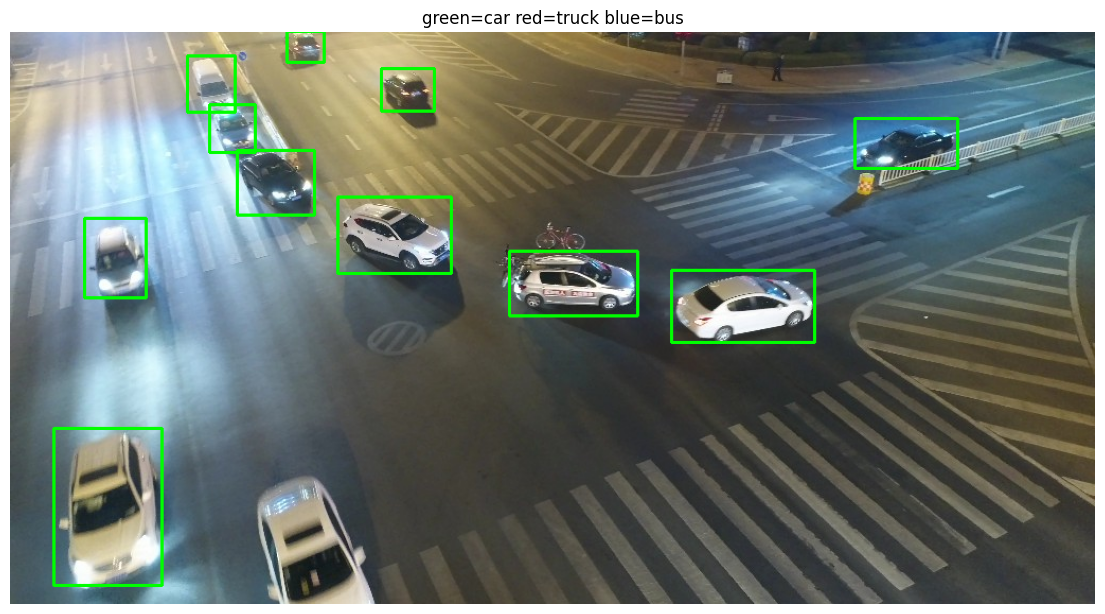

In [10]:
# Sanity check: draw the converted labels on a random training image
img_path = random.choice(glob.glob(f"{YOLO_DIR}/images/train/*.jpg"))
img = cv2.imread(img_path); ih, iw = img.shape[:2]
for line in open(img_path.replace("/images/", "/labels/").replace(".jpg", ".txt")).read().splitlines():
    c, xc, yc, bw, bh = map(float, line.split())
    x1, y1 = int((xc - bw / 2) * iw), int((yc - bh / 2) * ih)
    x2, y2 = int((xc + bw / 2) * iw), int((yc + bh / 2) * ih)
    cv2.rectangle(img, (x1, y1), (x2, y2), [(0, 255, 0), (0, 0, 255), (255, 0, 0)][int(c)], 2)
plt.figure(figsize=(14, 8)); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.title("green=car red=truck blue=bus"); plt.show()

# 2. Training
Transfer learning from COCO weights. Augmentations are chosen for drone imagery: vertical flips and rotations are valid because a top-down view has no "up".

In [11]:
RUNS_DIR = "/content/drive/MyDrive/uavdt_runs"

det_model = YOLO("yolov8s.pt")   # start from COCO weights (transfer learning)
det_model.train(
    data=f"{YOLO_DIR}/data.yaml",
    epochs=20,
    imgsz=1024,
    batch=8,              # lower to 4 if you get "CUDA out of memory"
    patience=8,           # stop early if val mAP stops improving
    mosaic=1.0, scale=0.5, fliplr=0.5, flipud=0.5, degrees=15,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    project=RUNS_DIR, name="yolov8s_uavdt", exist_ok=True,
    device=DEVICE,
)

Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/uavdt_yolo/data.yaml, degrees=15, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_uavdt, nbs=64, nms=None, opset=None, optimize=False, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b92f96b7120>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [12]:
# If Colab disconnected mid-training, run this instead of the cell above to resume:
# YOLO(f"{RUNS_DIR}/yolov8s_uavdt/weights/last.pt").train(resume=True)

# 3. Evaluation
Validation mAP at three inference resolutions. Vehicles in drone footage are tiny, so resolution matters.

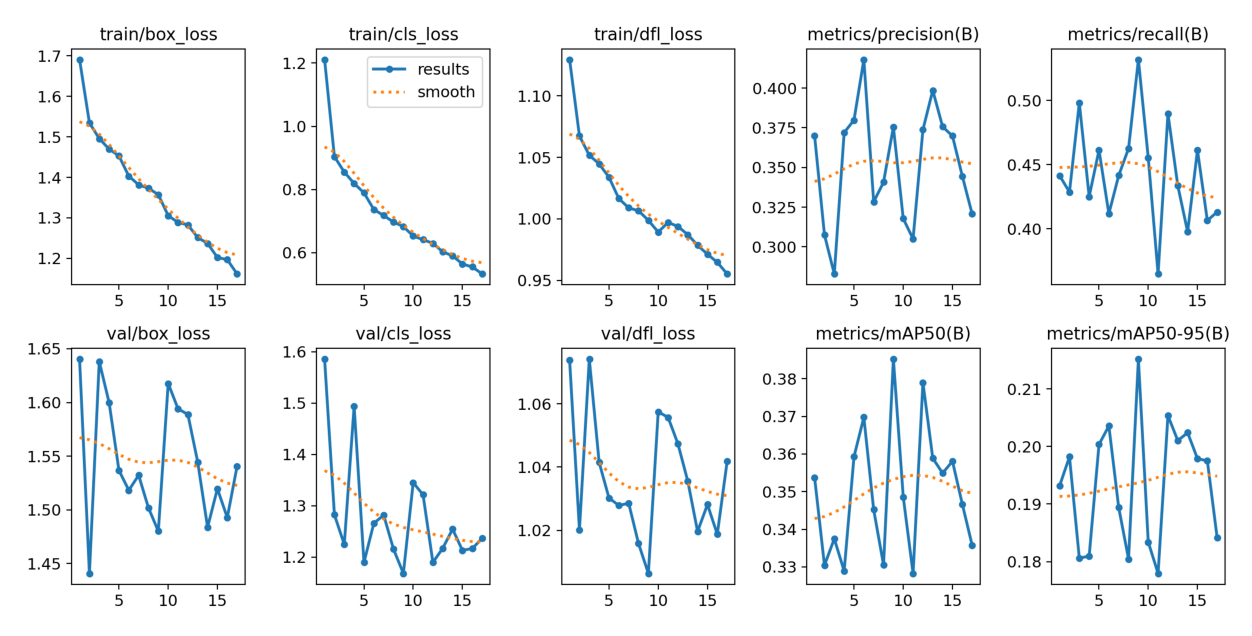

Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2549.4±600.3 MB/s, size: 186.7 KB)
val: Scanning /content/uavdt_yolo/labels/val.cache... 580 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 580/580 128.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 73/73 10.0it/s 7.3s
                   all        580      10587      0.376      0.539      0.367      0.199
Speed: 0.7ms preprocess, 6.8ms inference, 0.0ms loss, 1.4ms postprocess per image
Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3446.2±896.4 MB/s, size: 166.3 KB)
val: Scanning /content/uavdt_yolo/labels/val.cache... 580 images,

,imgsz,mAP50,mAP50-95
0,640,0.367,0.199
1,1024,0.386,0.216
2,1280,0.379,0.207


In [13]:
BEST = f"{RUNS_DIR}/yolov8s_uavdt/weights/best.pt"
plt.figure(figsize=(16, 8)); plt.imshow(plt.imread(f"{RUNS_DIR}/yolov8s_uavdt/results.png")); plt.axis("off"); plt.show()

rows = []
for s in [640, 1024, 1280]:
    m = YOLO(BEST).val(data=f"{YOLO_DIR}/data.yaml", imgsz=s, batch=8, plots=False, verbose=False, device=DEVICE)
    rows.append({"imgsz": s, "mAP50": m.box.map50, "mAP50-95": m.box.map})
display(pd.DataFrame(rows).round(3))

# 4. Speed estimation on a new drone video
**Calibration:** for a top-down camera, `metres per pixel ≈ 4.5 m / median car length in pixels`.
**Speed:** displacement of the track centre over a sliding window of frames, converted to km/h, smoothed with an exponential moving average, and capped at 200 km/h to reject tracking glitches.

In [14]:
# Upload a drone video from your computer
from google.colab import files
uploaded = files.upload()
VIDEO_PATH = list(uploaded.keys())[0]
print("Video:", VIDEO_PATH)

Saving drone-footage.mp4 to drone-footage.mp4
Video: drone-footage.mp4


Resolution: 1920x1080 | FPS: 30.0 | Frames: 323 | Duration: 10.8s


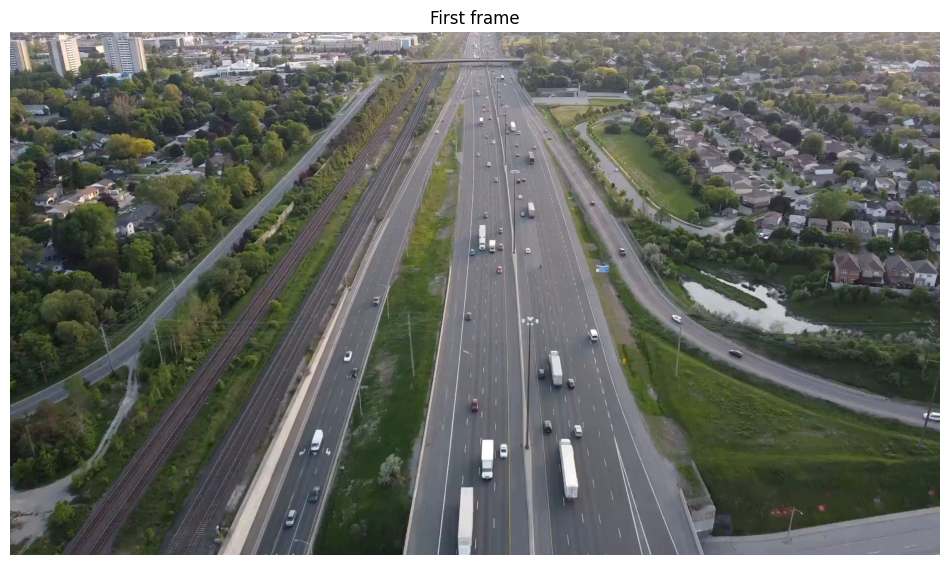

In [15]:
# Inspect the video
cap = cv2.VideoCapture(VIDEO_PATH)
FPS = cap.get(cv2.CAP_PROP_FPS) or 30
W, H = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
N = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
ok, first_frame = cap.read()
cap.release()

print(f"Resolution: {W}x{H} | FPS: {FPS:.1f} | Frames: {N} | Duration: {N / FPS:.1f}s")
plt.figure(figsize=(12, 7)); plt.imshow(cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.title("First frame"); plt.show()

In [16]:
def vehicle_class_ids(model):
    # Pick class ids whose names are vehicles, so this works for COCO *and* our custom UAVDT model
    wanted = {"car", "truck", "bus", "motorcycle", "van"}
    return [i for i, n in model.names.items() if n in wanted]


In [17]:
class SpeedEstimator:
    def __init__(self, fps, meters_per_pixel, window=10, alpha=0.3, max_kmh=200):
        self.fps, self.mpp, self.alpha, self.max_kmh = fps, meters_per_pixel, alpha, max_kmh
        self.min_points = max(3, window // 2)
        self.history = defaultdict(lambda: deque(maxlen=window))   # track_id -> [(frame, x, y), ...]
        self.speed = {}                                            # track_id -> smoothed km/h

    def update(self, tid, frame_idx, x, y):
        h = self.history[tid]
        h.append((frame_idx, x, y))
        if len(h) < self.min_points:
            return None                                   # not enough history yet
        (f0, x0, y0), (f1, x1, y1) = h[0], h[-1]
        dt = (f1 - f0) / self.fps                         # seconds
        dist_m = math.hypot(x1 - x0, y1 - y0) * self.mpp  # metres
        kmh = dist_m / dt * 3.6
        if kmh > self.max_kmh:                            # physically implausible -> ignore
            return self.speed.get(tid)
        prev = self.speed.get(tid)
        self.speed[tid] = kmh if prev is None else self.alpha * kmh + (1 - self.alpha) * prev
        return self.speed[tid]


def color_for(tid):
    rng = np.random.default_rng(int(tid))
    return tuple(int(c) for c in rng.integers(60, 255, 3))

In [18]:
def process_video(video_path, output_path, model, mpp, max_frames=MAX_FRAMES):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    w, h = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if max_frames:
        total = min(total, max_frames)
    writer = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

    vehicle_ids = vehicle_class_ids(model)
    tracker = DeepSort(
        max_age=int(fps),            # keep a lost track alive ~1 second (handles short occlusions)
        n_init=3,                    # confirm a track after 3 consecutive detections
        max_cosine_distance=0.3,     # appearance-matching threshold
        nn_budget=100,
        embedder="mobilenet",        # small CNN that produces appearance descriptors
        half=torch.cuda.is_available(), bgr=True,   # fp16 only works on GPU
        embedder_gpu=torch.cuda.is_available(),
    )
    speeds = SpeedEstimator(fps, mpp)
    trails = defaultdict(lambda: deque(maxlen=30))
    records = []

    for frame_idx in tqdm(range(total), desc="Processing"):
        ok, frame = cap.read()
        if not ok:
            break

        # 1) DETECT
        r = model.predict(frame, imgsz=IMG_SIZE, conf=CONF, classes=vehicle_ids, device=DEVICE, verbose=False)[0]
        dets = []
        for (x1, y1, x2, y2), c, k in zip(r.boxes.xyxy.cpu().numpy(), r.boxes.conf.cpu().numpy(), r.boxes.cls.cpu().numpy().astype(int)):
            dets.append(([float(x1), float(y1), float(x2 - x1), float(y2 - y1)], float(c), model.names[k]))  # DeepSORT wants [left, top, w, h]

        # 2) TRACK
        tracks = tracker.update_tracks(dets, frame=frame)

        # 3) SPEED + DRAW
        for t in tracks:
            if not t.is_confirmed() or t.time_since_update > 0:   # skip unconfirmed / currently-unseen tracks
                continue
            l, tp, rt, b = t.to_ltrb()                           # Kalman-smoothed box
            cx, cy = (l + rt) / 2, (tp + b) / 2
            kmh = speeds.update(t.track_id, frame_idx, cx, cy)
            trails[t.track_id].append((int(cx), int(cy)))

            col = color_for(t.track_id)
            cv2.rectangle(frame, (int(l), int(tp)), (int(rt), int(b)), col, 2)
            pts = np.array(trails[t.track_id], np.int32)
            if len(pts) > 1:
                cv2.polylines(frame, [pts], False, col, 2)
            label = f"#{t.track_id} " + (f"{kmh:.0f} km/h" if kmh is not None else "...")
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            cv2.rectangle(frame, (int(l), int(tp) - th - 6), (int(l) + tw + 4, int(tp)), col, -1)
            cv2.putText(frame, label, (int(l) + 2, int(tp) - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA)

            records.append({"frame": frame_idx, "time_s": frame_idx / fps, "track_id": int(t.track_id),
                            "cls": t.get_det_class(), "cx": cx, "cy": cy, "speed_kmh": kmh})

        cv2.putText(frame, f"frame {frame_idx}  vehicles {len(dets)}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
        writer.write(frame)

    cap.release(); writer.release()
    return pd.DataFrame(records)

In [19]:
def show_video(path, width=900):
    # OpenCV writes mp4v, which browsers can't play -> convert to H.264 with ffmpeg
    h264 = path.replace(".mp4", "_h264.mp4")
    os.system(f'ffmpeg -y -loglevel error -i "{path}" -vcodec libx264 -crf 28 -pix_fmt yuv420p "{h264}"')
    size_mb = os.path.getsize(h264) / 1e6
    if size_mb > 40:
        print(f"Video is {size_mb:.0f} MB, too big to preview here. Download it instead (next cell).")
    else:
        data = b64encode(open(h264, "rb").read()).decode()
        display(HTML(f'<video width="{width}" controls><source src="data:video/mp4;base64,{data}" type="video/mp4"></video>'))
    return h264

### 4a. Baseline: COCO-pretrained YOLOv8s (no fine-tuning)

In [20]:
model = YOLO("yolov8s.pt")   # COCO-pretrained baseline; the fine-tuned model is used in 4b

In [21]:
def estimate_meters_per_pixel(model, video_path, n_samples=30, car_length_m=CAR_LENGTH_M):
    car_ids = [i for i, n in model.names.items() if n == "car"]
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    lengths = []
    for idx in np.linspace(0, total - 1, n_samples).astype(int):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ok, frame = cap.read()
        if not ok:
            continue
        r = model.predict(frame, imgsz=IMG_SIZE, conf=0.4, classes=car_ids, device=DEVICE, verbose=False)[0]
        for x1, y1, x2, y2 in r.boxes.xyxy.cpu().numpy():
            lengths.append(max(x2 - x1, y2 - y1))   # longer box side = car length (top-down view)
    cap.release()
    if len(lengths) < 10:
        raise ValueError("Too few cars found to calibrate. Set METERS_PER_PIXEL manually.")
    med = float(np.median(lengths))
    print(f"Used {len(lengths)} car boxes, median car length = {med:.1f}px")
    return car_length_m / med

mpp = METERS_PER_PIXEL or estimate_meters_per_pixel(model, VIDEO_PATH)
print(f"Scale: {mpp:.4f} metres per pixel  (1 metre = {1 / mpp:.1f} px)")

Used 70 car boxes, median car length = 30.6px
Scale: 0.1471 metres per pixel  (1 metre = 6.8 px)


In [ ]:
OUTPUT_PATH = "/content/speed_output.mp4"
df = process_video(VIDEO_PATH, OUTPUT_PATH, model, mpp)
df.to_csv("/content/speeds.csv", index=False)
print("Saved annotated video and speeds.csv;", df.track_id.nunique(), "vehicles tracked")

h264_path = show_video(OUTPUT_PATH)

### 4b. Fine-tuned UAVDT model

In [ ]:
model = YOLO(BEST)
print("Classes:", model.names)
IMG_SIZE = 1024        # match the training resolution (best mAP in the table above)
mpp = METERS_PER_PIXEL or estimate_meters_per_pixel(model, VIDEO_PATH)
df_custom = process_video(VIDEO_PATH, "/content/speed_output_custom.mp4", model, mpp)
df_custom.to_csv("/content/speeds_custom.csv", index=False)
print("Vehicles tracked -> pretrained:", df.track_id.nunique(), "| custom:", df_custom.track_id.nunique())
show_video("/content/speed_output_custom.mp4")

In [24]:
# Optional: make a short GIF of the result for the GitHub README
!ffmpeg -y -loglevel error -i /content/speed_output_custom_h264.mp4 -vf "fps=10,scale=720:-1" -t 6 /content/demo.gif
files.download("/content/demo.gif")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 5. Limitations and next steps
- Speed assumes a roughly **straight-down camera** and a flat road, so one metres-per-pixel value is used for the whole frame.
- Calibration relies on an average car length, so errors in that assumption scale every speed proportionally.
- Speeds are **not validated against ground truth** (e.g. GPS). That would be the next step.
- Truck and bus are rare classes in UAVDT, so their per-class mAP is lower than for cars.